<a href="https://colab.research.google.com/github/Divya6859/pulsar-star-classification/blob/main/Pulsar_Star_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**The goal of this project is to build a Machine Learning model to classify whether a given astronomical signal is a pulsar or not based on statistical features of the signal.**

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score


In [29]:
df = pd.read_csv('https://raw.githubusercontent.com/alexandrehsd/Predicting-Pulsar-Stars/master/pulsar_stars.csv')
df

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0
...,...,...,...,...,...,...,...,...,...
17893,136.429688,59.847421,-0.187846,-0.738123,1.296823,12.166062,15.450260,285.931022,0
17894,122.554688,49.485605,0.127978,0.323061,16.409699,44.626893,2.945244,8.297092,0
17895,119.335938,59.935939,0.159363,-0.743025,21.430602,58.872000,2.499517,4.595173,0
17896,114.507812,53.902400,0.201161,-0.024789,1.946488,13.381731,10.007967,134.238910,0


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17898 entries, 0 to 17897
Data columns (total 9 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0    Mean of the integrated profile                17898 non-null  float64
 1    Standard deviation of the integrated profile  17898 non-null  float64
 2    Excess kurtosis of the integrated profile     17898 non-null  float64
 3    Skewness of the integrated profile            17898 non-null  float64
 4    Mean of the DM-SNR curve                      17898 non-null  float64
 5    Standard deviation of the DM-SNR curve        17898 non-null  float64
 6    Excess kurtosis of the DM-SNR curve           17898 non-null  float64
 7    Skewness of the DM-SNR curve                  17898 non-null  float64
 8   target_class                                   17898 non-null  int64  
dtypes: float64(8), int64(1)
memory usage: 1.2 MB


In [31]:
df.describe()

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
count,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000
mean,111.079968,46.549532,0.477857,1.770279,12.614400,26.326515,8.303556,104.857709,0.091574
std,25.652935,6.843189,1.064040,6.167913,29.472897,19.470572,4.506092,106.514540,0.288432
min,5.812500,24.772042,-1.876011,-1.791886,0.213211,7.370432,-3.139270,-1.976976,0.000000
25%,100.929688,42.376018,0.027098,-0.188572,1.923077,14.437332,5.781506,34.960504,0.000000
50%,115.078125,46.947479,0.223240,0.198710,2.801839,18.461316,8.433515,83.064556,0.000000
75%,127.085938,51.023202,0.473325,0.927783,5.464256,28.428104,10.702959,139.309330,0.000000
max,192.617188,98.778911,8.069522,68.101622,223.392141,110.642211,34.539844,1191.000837,1.000000


In [32]:
df.isnull().sum()

,0
Mean of the integrated profile,0
Standard deviation of the integrated profile,0
Excess kurtosis of the integrated profile,0
Skewness of the integrated profile,0
Mean of the DM-SNR curve,0
Standard deviation of the DM-SNR curve,0
Excess kurtosis of the DM-SNR curve,0
Skewness of the DM-SNR curve,0
target_class,0


In [33]:
df.duplicated().sum()

np.int64(0)

In [34]:
df.shape

(17898, 9)

In [35]:
df['target_class'].value_counts()

,count
target_class,
0,16259
1,1639


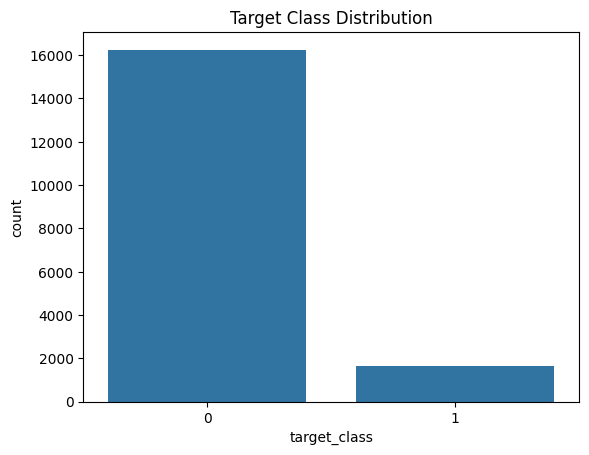

In [36]:
sns.countplot(x='target_class', data=df)
plt.title("Target Class Distribution")
plt.show()

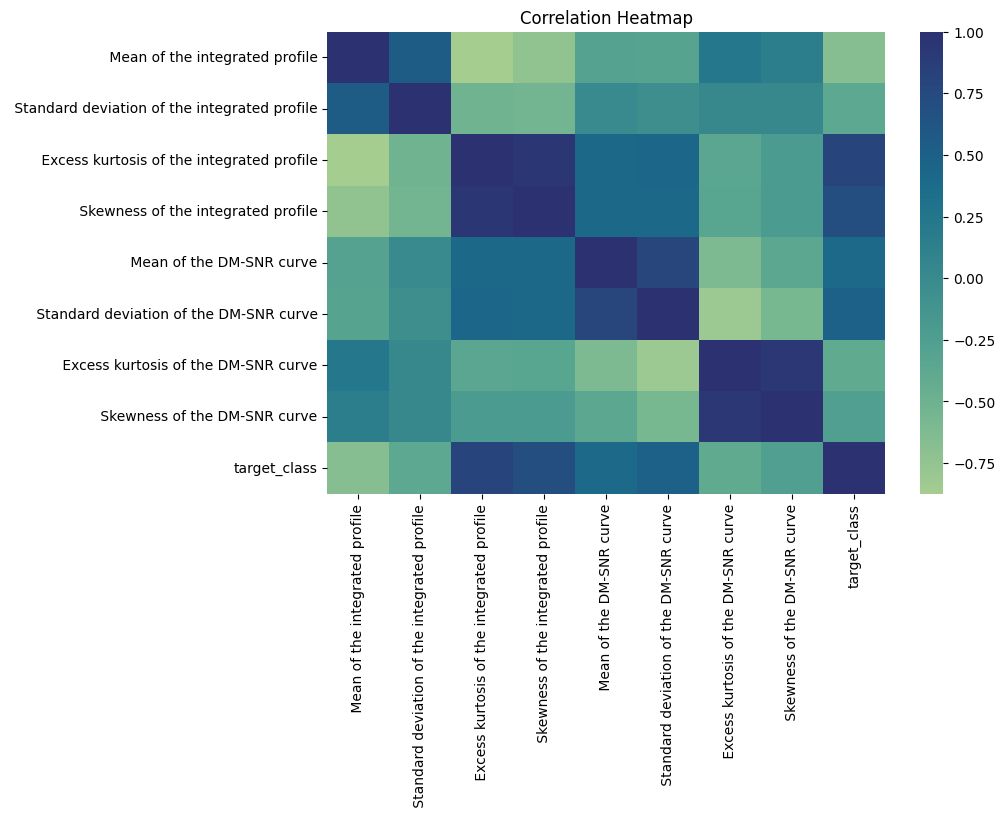

In [37]:
plt.figure(figsize=(9,6))
sns.heatmap(df.corr(), annot=False, cmap='crest')
plt.title("Correlation Heatmap")
plt.show()

Feature Distribution

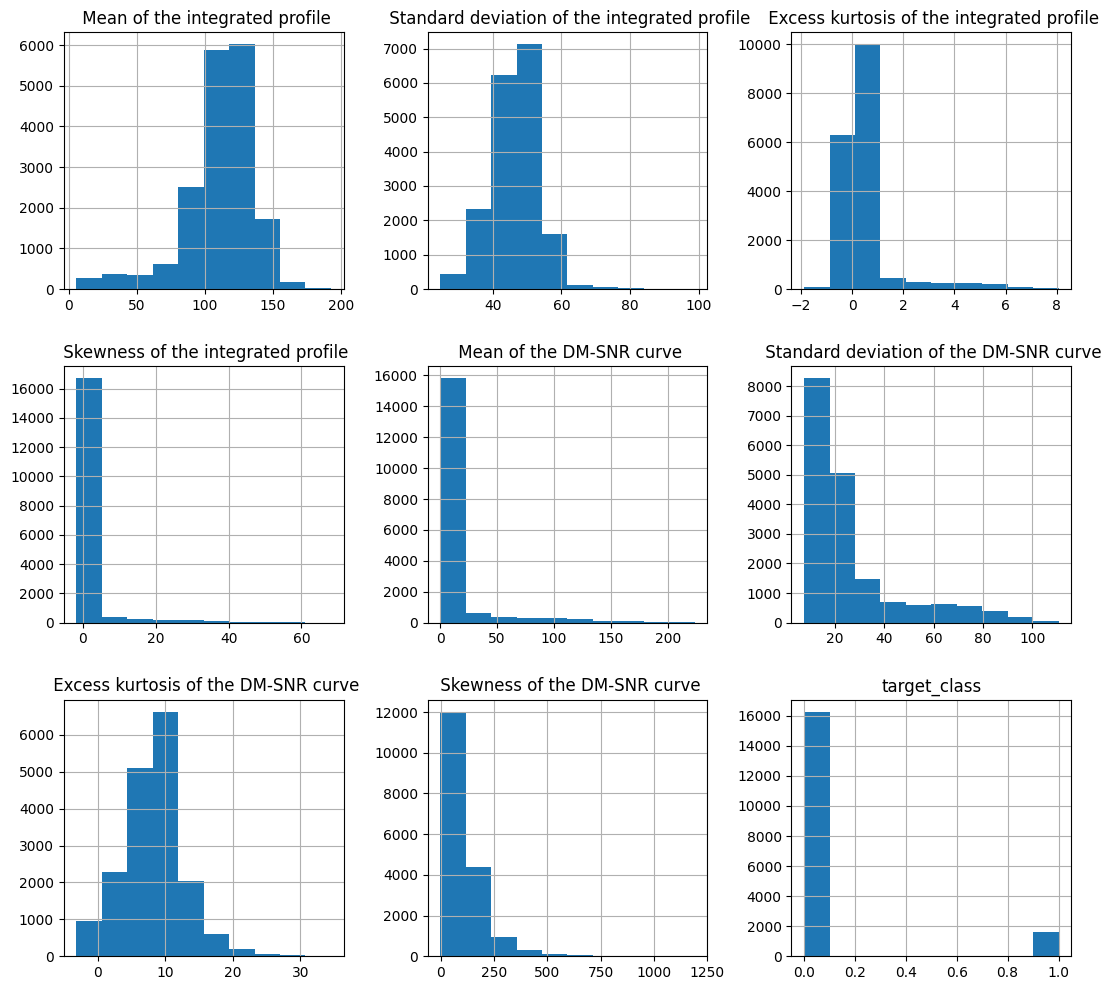

In [38]:
df.hist(figsize=(13,12))
plt.show()

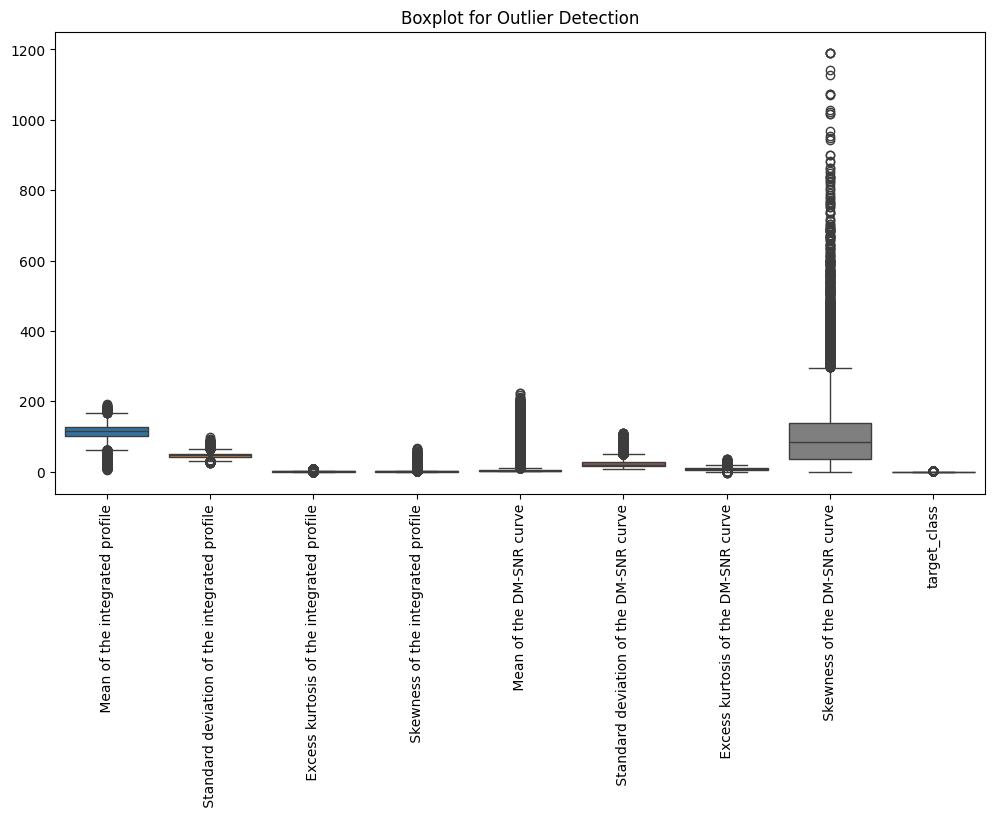

In [39]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Boxplot for Outlier Detection")
plt.show()

Split Features & Target

In [40]:
X = df.drop('target_class', axis=1)
y = df['target_class']

Train-Test Split

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Feature Scaling

In [42]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

MODEL BUILDING

Random Forest

In [43]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

SVM (Different Kernels)

In [44]:
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train_scaled, y_train)

svm_poly = SVC(kernel='poly')
svm_poly.fit(X_train_scaled, y_train)

svm_sigmoid = SVC(kernel='sigmoid')
svm_sigmoid.fit(X_train_scaled, y_train)

svm_linear_pred = svm_linear.predict(X_test_scaled)
svm_poly_pred = svm_poly.predict(X_test_scaled)
svm_sigmoid_pred = svm_sigmoid.predict(X_test_scaled)

XGBoost

In [45]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

MODEL EVALUATION

In [46]:
def evaluate_model(name, y_test, y_pred):
    print(f"\n{name}")
    print("F1 Score:", f1_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))

Evaluate All Models

In [47]:
evaluate_model("Random Forest", y_test, rf_pred)
evaluate_model("SVM Linear", y_test, svm_linear_pred)
evaluate_model("SVM Polynomial", y_test, svm_poly_pred)
evaluate_model("SVM Sigmoid", y_test, svm_sigmoid_pred)
evaluate_model("XGBoost", y_test, xgb_pred)


Random Forest
F1 Score: 0.89937106918239
Recall: 0.8719512195121951
Confusion Matrix:
 [[3230   22]
 [  42  286]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      3252
           1       0.93      0.87      0.90       328

    accuracy                           0.98      3580
   macro avg       0.96      0.93      0.94      3580
weighted avg       0.98      0.98      0.98      3580


SVM Linear
F1 Score: 0.881578947368421
Recall: 0.8170731707317073
Confusion Matrix:
 [[3240   12]
 [  60  268]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99      3252
           1       0.96      0.82      0.88       328

    accuracy                           0.98      3580
   macro avg       0.97      0.91      0.94      3580
weighted avg       0.98      0.98      0.98      3580


SVM Polynomial
F1 Score: 0.8707037643207856
Recall: 0.810975609756097

Model Comparison

In [48]:
results = pd.DataFrame({
    "Model": ["Random Forest", "SVM Linear", "SVM Poly", "SVM Sigmoid", "XGBoost"],
    "F1 Score": [
        f1_score(y_test, rf_pred),
        f1_score(y_test, svm_linear_pred),
        f1_score(y_test, svm_poly_pred),
        f1_score(y_test, svm_sigmoid_pred),
        f1_score(y_test, xgb_pred)
    ],
    "Recall": [
        recall_score(y_test, rf_pred),
        recall_score(y_test, svm_linear_pred),
        recall_score(y_test, svm_poly_pred),
        recall_score(y_test, svm_sigmoid_pred),
        recall_score(y_test, xgb_pred)
    ]
})

print(results)

           Model  F1 Score    Recall
0  Random Forest  0.899371  0.871951
1     SVM Linear  0.881579  0.817073
2       SVM Poly  0.870704  0.810976
3    SVM Sigmoid  0.314642  0.307927
4        XGBoost  0.876543  0.865854


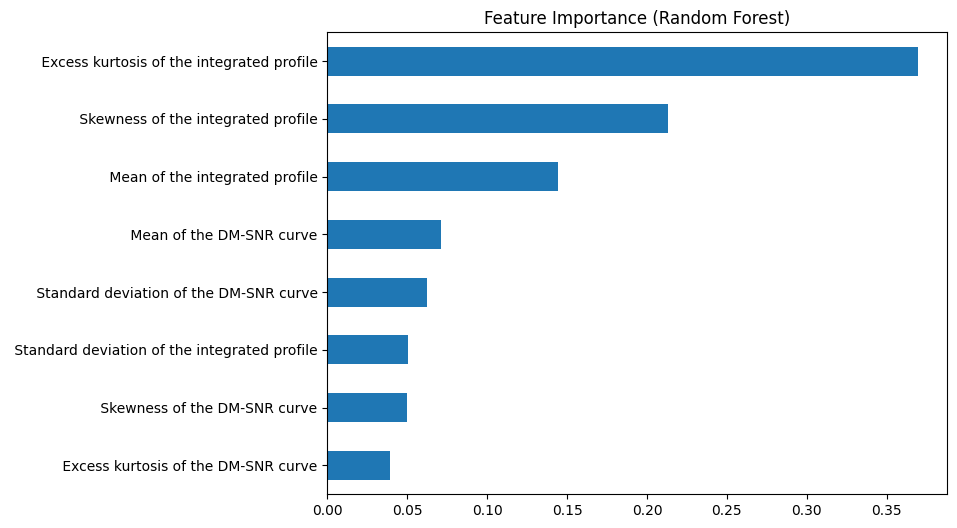

In [49]:
importances = rf.feature_importances_

feat_imp = pd.Series(importances, index=X.columns)
feat_imp.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance (Random Forest)")
plt.show()

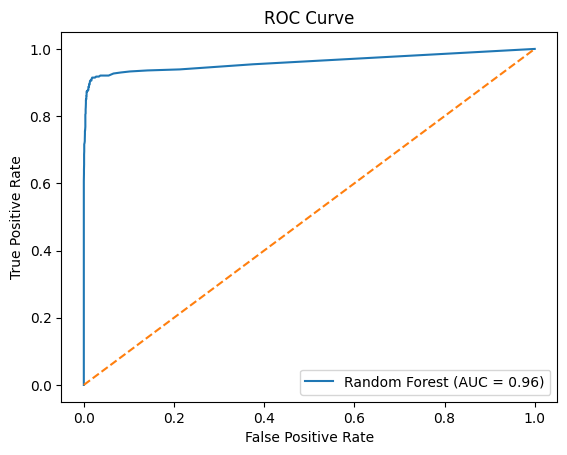

In [50]:
from sklearn.metrics import roc_curve, auc

# Random Forest probabilities
rf_probs = rf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, rf_probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Prediction on Test Data

In [51]:
def predict_and_validate(model, X_test, y_test, index):

    sample = X_test.iloc[index:index+1]
    actual = y_test.iloc[index]

    prediction = model.predict(sample)[0]
    probability = model.predict_proba(sample)[0]

    print("Sample Index:", index)
    print("Actual Value:", actual)
    print("Predicted Value:", prediction)

    if prediction == actual:
        print("Correct Prediction")
    else:
        print("Wrong Prediction")

    print("Confidence:")
    print("Not Pulsar (0):", round(probability[0], 2))
    print("Pulsar (1):", round(probability[1], 2))
predict_and_validate(rf, X_test, y_test, 0)

Sample Index: 0
Actual Value: 0
Predicted Value: 0
Correct Prediction
Confidence:
Not Pulsar (0): 1.0
Pulsar (1): 0.0


In [52]:
for i in range(10):
    print("\n--------------------------")
    predict_and_validate(rf, X_test, y_test, i)


--------------------------
Sample Index: 0
Actual Value: 0
Predicted Value: 0
Correct Prediction
Confidence:
Not Pulsar (0): 1.0
Pulsar (1): 0.0

--------------------------
Sample Index: 1
Actual Value: 0
Predicted Value: 0
Correct Prediction
Confidence:
Not Pulsar (0): 0.99
Pulsar (1): 0.01

--------------------------
Sample Index: 2
Actual Value: 0
Predicted Value: 0
Correct Prediction
Confidence:
Not Pulsar (0): 0.96
Pulsar (1): 0.04

--------------------------
Sample Index: 3
Actual Value: 0
Predicted Value: 0
Correct Prediction
Confidence:
Not Pulsar (0): 1.0
Pulsar (1): 0.0

--------------------------
Sample Index: 4
Actual Value: 0
Predicted Value: 0
Correct Prediction
Confidence:
Not Pulsar (0): 1.0
Pulsar (1): 0.0

--------------------------
Sample Index: 5
Actual Value: 0
Predicted Value: 0
Correct Prediction
Confidence:
Not Pulsar (0): 0.99
Pulsar (1): 0.01

--------------------------
Sample Index: 6
Actual Value: 0
Predicted Value: 0
Correct Prediction
Confidence:
Not Puls

Predict on New Custom Input

In [53]:
new_data = [[140.5625, 55.683, -0.234, 0.123, 3.199, 19.110, 7.975, -0.456]]
new_df = pd.DataFrame(new_data, columns=X.columns)
prediction = rf.predict(new_df)

if prediction[0] == 1:
    print("This signal is a Pulsar ⭐")
else:
    print("This signal is NOT a Pulsar ❌")

This signal is NOT a Pulsar ❌
